## Direct Classification: Comparison

In this part we compare the five direct classifiers of the `1D` notebooks with the label of the regression models of `1B`, which predict the four targets and then apply the thresholds of `definition_bonne_soudure.md`. The question is whether going through the four regressions is better than predicting the label directly. Each model is tuned and evaluated in its own notebook, which adds its rows to `results.csv`, and this notebook reads that table. Only the best model of each approach is refitted at the end, to compare their predictions deposit by deposit.

### Tuned hyperparameters

| Model | Tuned on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score | Selected | Nested F1 |
|---|---|---|---|
| Naive Bayes classifier | `var_smoothing`, then the number of principal components given to the naive Bayes (1 to 26) | PCA with 23 components | 0.66 |
| k-NN classifier | `n_neighbors` (1 to 61), uniform or distance-weighted vote, Manhattan or Euclidean distance | 1 neighbour, Euclidean distance | 0.75 |
| SVM classifier | Linear, RBF and polynomial kernels, `C` from 0.001 to 10,000, `gamma` from 0.0001 to 10 (RBF), degree 2 or 3 (polynomial) | Polynomial kernel of degree 2, `C` = 100 | 0.85 |
| Pruned tree classifier | `ccp_alpha`, every value of the pruning path (22 values) | 23 leaves | 0.70 |
| Random forest classifier | `max_features` in {0.1, 0.2, 0.33, 0.5, 0.75, 1.0} and `min_samples_leaf` in {1, 2, 4, 8}, 200 trees | `max_features` of 0.1, `min_samples_leaf` of 1 | 0.70 |

The nested F1 is computed at the end of each notebook: the grid search is redone for each fold without it, so it is not inflated by choosing the hyperparameters on the folds of the evaluation. The F1 of `results.csv` is 0.70, 0.80, 0.84, 0.72 and 0.75 for these five models.

### Main observations

- **Best of each approach:** The SVM classifier and the Extra-Trees of `1B` (four regressions and the thresholds) have the same F1 on the label, 0.84. The SVM catches more bad welds (recall of 0.83 against 0.72), the Extra-Trees raise no false alarm (precision of 1.00 against 0.85). On the 175 deposits, their numbers of errors do not differ significantly (23 and 26, McNemar p = 0.73). The gap in false alarms is significant (p < 0.001), the gap in missed bad welds not quite (p = 0.08).
- **Model by model:** With the same model, going through the regressions is better or equal: 0.77 against 0.72 for the pruned trees, 0.76 against 0.75 for the random forests. The direct approach only wins with the SVM and the k-NN, which have no regression counterpart in `1B`.
- **Data:** The direct classifiers learn from the 175 labelled deposits only. The regressions learn each target on every row where it is measured (558 to 723 rows), including the 321 deposits of the train set whose label is unknown.
- **Different errors:** The two best models are both wrong on only 8 deposits. Declaring non-conforming a deposit flagged by either of them catches 75 of the 83 non-conforming deposits (recall of 0.90) for 12 false alarms (F1 of 0.88). This rule is chosen after seeing the errors, so it should be confirmed on the test set.
- **Beyond the scores:** The regressions tell which criterion fails, and adapt to another class of the standard by changing the thresholds only, whereas a direct classifier must be retrained on new labels. In return, a direct classifier gives a score whose threshold sets the trade-off between missed bad welds and false alarms.
- **Conclusion:** Predicting the label directly is not worse than going through the four regressions: the best direct classifier matches the best regressions on the F1. The choice depends on the cost of the errors: the SVM if a missed bad weld costs more than a false alarm, the regressions if false alarms are costly or if the failing criterion must be known.

### Operations in order

1. Load `results.csv` with `load_results`, and keep the label rows of the baseline, of the four tree models of `1B` and of the five classifiers of `1D`.
2. Compare the F1, the recall and the precision on the non-conforming deposits, with the rule that declares every deposit non-conforming.
3. Plot the F1 and the recall of each model.
4. Compare the label per family.
5. Compare the two approaches model by model.
6. Refit the Extra-Trees of `1B4_extra_trees` and the SVM of `1D3_svm` with their selected hyperparameters, and compare their predictions deposit by deposit with McNemar's test.
7. Plot the precision-recall curve of the SVM, with the points of the Extra-Trees and of their combination.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import binomtest
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.svm import SVC

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, TARGETS, CHARPY, REPORT_FAMILIES, load_train, load_results, deposit_data,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, oof_predict_label,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
regression = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees"]
direct = ["Naive Bayes classifier", "k-NN classifier", "SVM classifier", "Pruned tree classifier", "Random forest classifier"]
models = regression + direct

results = load_results()
label = results[(results["target"] == "label") & results["model"].isin(models)].set_index(["model", "family"])
overall = label.xs("all", level="family").reindex(models)

share_nc = overall["n_nc"].iloc[0] / overall["n_clf"].iloc[0]
table = overall[["F1_nc", "recall_nc", "accuracy", "precision_good"]].copy()
table["precision_nc"] = table["F1_nc"] * table["recall_nc"] / (2 * table["recall_nc"] - table["F1_nc"])
table.loc["Every deposit non-conforming"] = [2 * share_nc / (1 + share_nc), 1.0, share_nc, float("nan"), share_nc]
table.insert(0, "approach", ["regressions + thresholds"] * len(regression) + ["direct classification"] * len(direct) + ["reference rule"])
table.round(2)

,approach,F1_nc,recall_nc,accuracy,precision_good,precision_nc
model,,,,,,
Baseline (mean),regressions + thresholds,0.00,0.00,0.53,0.53,NaN
Pruned CART,regressions + thresholds,0.77,0.81,0.77,0.81,0.73
Bagging,regressions + thresholds,0.81,0.72,0.84,0.79,0.92
Random forest,regressions + thresholds,0.76,0.64,0.81,0.75,0.93
Extra-Trees,regressions + thresholds,0.84,0.72,0.87,0.80,1.00
Naive Bayes classifier,direct classification,0.70,0.69,0.72,0.73,0.71
k-NN classifier,direct classification,0.80,0.82,0.81,0.83,0.78
SVM classifier,direct classification,0.84,0.83,0.85,0.85,0.85
Pruned tree classifier,direct classification,0.72,0.71,0.74,0.75,0.74


The label rows of `results.csv` on all the labelled deposits: 175 deposits, 83 of them non-conforming. `results.csv` only stores the F1 and the recall, the precision is deduced from them: F1 = 2PR / (P + R) gives P = F1 × R / (2R − F1). The last row is the rule that declares every deposit non-conforming, the reference of `0_baseline`.

- **Regressions and thresholds:** The ensembles have a high precision (0.92 to 1.00) and a lower recall (0.64 to 0.72). They smooth their predictions toward the mean of each target (see the `1B` notebooks), so they only declare non-conforming the deposits clearly beyond a threshold: the Extra-Trees raise no false alarm on the 175 deposits. The pruned tree is the exception (precision of 0.73, recall of 0.81).
- **Direct classification:** The classifiers are tuned on the F1 of the label itself, so their precision and their recall are balanced: 0.85 and 0.83 for the SVM, 0.78 and 0.82 for the k-NN.
- **F1:** The SVM (0.84) and the Extra-Trees (0.84) come first, then the bagging (0.81) and the k-NN (0.80). Every model except the baseline is above the 0.64 of the reference rule, the naive Bayes only by 0.06.

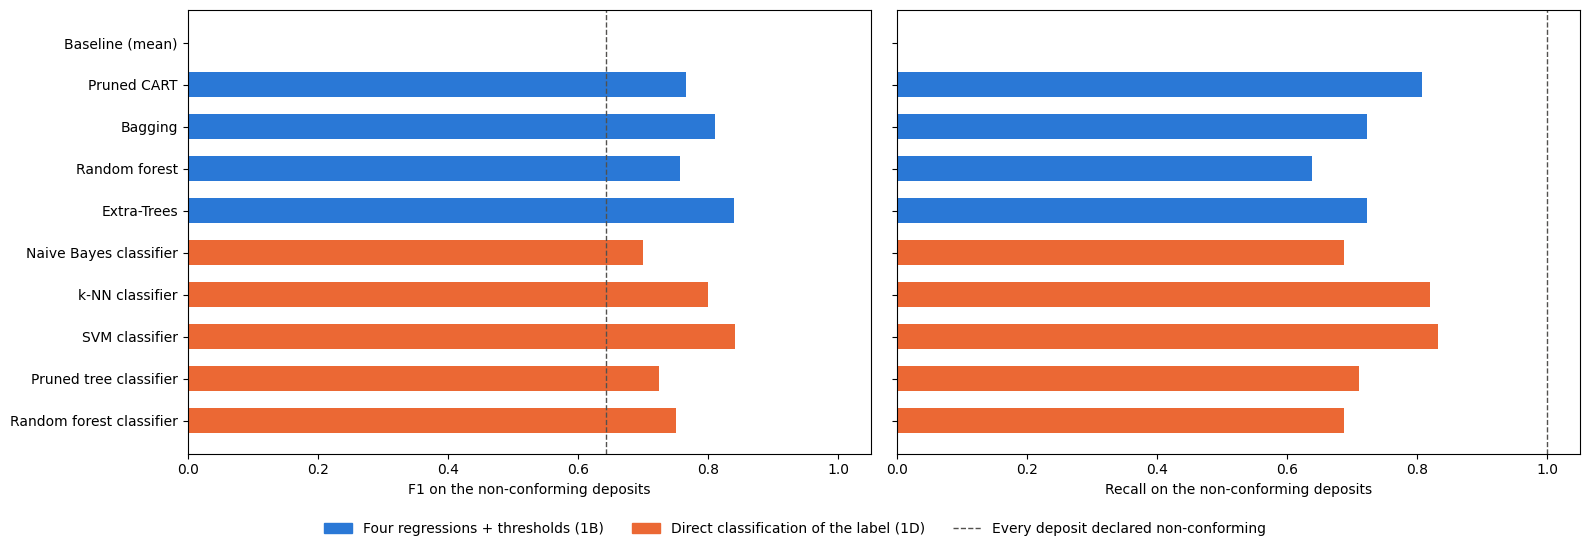

In [4]:
colors = ["#b5b4ae"] + ["#2a78d6"] * (len(regression) - 1) + ["#eb6834"] * len(direct)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, metric, name in zip(axes, ["F1_nc", "recall_nc"], ["F1", "Recall"]):
    ax.barh(models, overall[metric], height=0.6, color=colors)
    ax.axvline(table.loc["Every deposit non-conforming", metric], color="#52514e", linewidth=1, linestyle="--")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(f"{name} on the non-conforming deposits")
axes[0].invert_yaxis()
handles = [
    Patch(color="#2a78d6", label="Four regressions + thresholds (1B)"),
    Patch(color="#eb6834", label="Direct classification of the label (1D)"),
    Line2D([], [], color="#52514e", linewidth=1, linestyle="--", label="Every deposit declared non-conforming"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

The blue bars are the label of the regression models of `1B`, the orange bars the direct classifiers of `1D`, and the dashed line the rule that declares every deposit non-conforming (F1 of 0.64, recall of 1).

- **F1:** The two approaches overlap: the best model of each is at 0.84, and both have models between 0.70 and 0.81.
- **Recall:** The SVM (0.83), the k-NN (0.82) and the pruned regression trees (0.81) catch the most non-conforming deposits. The regression ensembles miss 23 to 30 of the 83.

In [5]:
display(label.xs("Baseline (mean)", level="model")[["n_clf", "n_nc"]].T)

label[["F1_nc", "recall_nc", "accuracy", "precision_good"]].unstack("family").reindex(index=models).reindex(columns=REPORT_FAMILIES, level="family").round(2)

family,all,C-Mn,CrMo2,CrMo91
n_clf,175,161,8,6
n_nc,83,79,1,3


F1_nc                    recall_nc              \
family                     all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2   
model                                                                     
Baseline (mean)           0.00  0.00  0.00   0.00      0.00  0.00   0.0   
Pruned CART               0.77  0.78  1.00   0.00      0.81  0.84   1.0   
Bagging                   0.81  0.83  0.00   0.50      0.72  0.75   0.0   
Random forest             0.76  0.77  0.00   0.50      0.64  0.66   0.0   
Extra-Trees               0.84  0.85  0.00   0.80      0.72  0.73   0.0   
Naive Bayes classifier    0.70  0.71  0.00   0.50      0.69  0.70   0.0   
k-NN classifier           0.80  0.81  1.00   0.50      0.82  0.82   1.0   
SVM classifier            0.84  0.85  0.67   0.67      0.83  0.84   1.0   
Pruned tree classifier    0.72  0.74  0.00   0.40      0.71  0.73   0.0   
Random forest classifier  0.75  0.78  0.00   0.29      0.69  0.71   0.0   

                                accuracy                    precision_good  \
family                   CrMo91      all  C-Mn CrMo2 CrMo91            all   
model                                                                        
Baseline (mean)            0.00     0.53  0.51  0.88   0.50           0.53   
Pruned CART                0.00     0.77  0.77  1.00   0.33           0.81   
Bagging                    0.33     0.84  0.84  0.88   0.67           0.79   
Random forest              0.33     0.81  0.81  0.88   0.67           0.75   
Extra-Trees                0.67     0.87  0.87  0.88   0.83           0.80   
Naive Bayes classifier     0.67     0.72  0.73  0.88   0.33           0.73   
k-NN classifier            0.67     0.81  0.81  1.00   0.33           0.83   
SVM classifier             0.67     0.85  0.86  0.88   0.67           0.85   
Pruned tree classifier     0.33     0.74  0.75  0.88   0.50           0.75   
Random forest classifier   0.33     0.78  0.81  0.75   0.17           0.75   

                                             
family                    C-Mn CrMo2 CrMo91  
model                                        
Baseline (mean)           0.51  0.88   0.50  
Pruned CART               0.82  1.00   0.40  
Bagging                   0.79  0.88   0.60  
Random forest             0.74  0.88   0.60  
Extra-Trees               0.80  0.88   0.75  
Naive Bayes classifier    0.72  0.88   0.00  
k-NN classifier           0.82  1.00   0.00  
SVM classifier            0.85  1.00   0.67  
Pruned tree classifier    0.75  0.88   0.50  
Random forest classifier  0.76  0.86   0.00

The first table gives the number of labelled deposits (`n_clf`) and of non-conforming deposits (`n_nc`) per family, the second the F1 and the recall of each model per family.

- **C-Mn:** 161 of the 175 deposits, so the same ranking as on all the deposits, with an F1 of 0.85 for the SVM and the Extra-Trees.
- **Cr-Mo:** 8 CrMo2 deposits with a single non-conforming one, and 6 CrMo91 deposits with 3 non-conforming ones. On CrMo2, the recall is 0 or 1 depending on whether this one deposit is caught (by the pruned regression trees, the k-NN and the SVM). These values cannot be used to compare the models.

In [6]:
pairs = {
    "Pruned tree": ("Pruned CART", "Pruned tree classifier"),
    "Random forest": ("Random forest", "Random forest classifier"),
    "Best of each approach": ("Extra-Trees", "SVM classifier"),
}

pd.DataFrame({
    comparison: {
        "regressions": regressions, "direct": classifier,
        "F1_regressions": round(overall.loc[regressions, "F1_nc"], 2), "F1_direct": round(overall.loc[classifier, "F1_nc"], 2),
        "recall_regressions": round(overall.loc[regressions, "recall_nc"], 2), "recall_direct": round(overall.loc[classifier, "recall_nc"], 2),
    }
    for comparison, (regressions, classifier) in pairs.items()
}).T

,regressions,direct,F1_regressions,F1_direct,recall_regressions,recall_direct
Pruned tree,Pruned CART,Pruned tree classifier,0.77,0.72,0.81,0.71
Random forest,Random forest,Random forest classifier,0.76,0.75,0.64,0.69
Best of each approach,Extra-Trees,SVM classifier,0.84,0.84,0.72,0.83


The same kind of model, through the four regressions and the thresholds (`1B`) or trained on the label (`1D`).

- **Pruned tree:** The regressions are better on both metrics (F1 of 0.77 against 0.72, recall of 0.81 against 0.71). Each regression tree learns from 558 to 723 rows, the classification tree from 175 deposits.
- **Random forest:** The same F1 (0.76 against 0.75), and a higher recall for the classifier (0.69 against 0.64).
- **Best of each approach:** The same F1 (0.84), and 11 more points of recall for the SVM.
- **Reading:** With the same model, learning the four targets on more rows is worth at least as much as learning the label. The direct approach catches up through the SVM, which handles the 175 deposits well (see its notebook).

In [7]:
train = load_train()
deposits = deposit_data(train)

extra_trees = {target: ExtraTreesRegressor(n_estimators=200, max_features=1.0 if target == CHARPY else 0.5, random_state=SEED) for target in TARGETS}
preds = {target: oof_predict(model, train, target) for target, model in extra_trees.items()}
regression_labels = deposit_labels(train, true_criteria(train), predicted_criteria(train, preds))

svm = oof_predict_label(SVC(kernel="poly", degree=2, coef0=1, C=100), train)

paired = pd.DataFrame({
    "true_nc": deposits["true_nc"],
    "extra_trees": regression_labels["pred_nc"].reindex(deposits.index),
    "svm": svm["pred_nc"],
})
paired["either"] = paired["extra_trees"] | paired["svm"]

pd.DataFrame({
    name: {
        "F1": f1_score(paired["true_nc"], paired[name]),
        "recall": recall_score(paired["true_nc"], paired[name]),
        "precision": precision_score(paired["true_nc"], paired[name]),
        "missed": ((paired["true_nc"] == 1) & (paired[name] == 0)).sum(),
        "false_alarms": ((paired["true_nc"] == 0) & (paired[name] == 1)).sum(),
    }
    for name in ["extra_trees", "svm", "either"]
}).T.astype({"missed": int, "false_alarms": int}).round(3)

,F1,recall,precision,missed,false_alarms
extra_trees,0.839,0.723,1.000,23,0
svm,0.841,0.831,0.852,14,12
either,0.882,0.904,0.862,8,12


This is the only training of this notebook: the Extra-Trees of `1B4_extra_trees` (200 trees, `max_features` of 0.5 for the tensile targets and 1.0 for Charpy, fully grown trees) and the SVM of `1D3_svm` (polynomial kernel of degree 2, `C` = 100) are refitted with their selected hyperparameters, on the same folds and with the same seed. `deposit_labels` gives the label predicted by the four regressions and the thresholds, `oof_predict_label` that of the SVM, for the same 175 deposits. `either` declares non-conforming a deposit flagged by at least one of the two.

- **Same results:** The F1 and the recall are those of `results.csv` (0.839 and 0.723 for the Extra-Trees, 0.841 and 0.831 for the SVM).
- **Errors:** The Extra-Trees miss 23 non-conforming deposits without any false alarm, the SVM misses 14 and raises 12 false alarms.
- **Either of the two:** Only 8 non-conforming deposits are missed (recall of 0.90), for the 12 false alarms of the SVM (F1 of 0.88, precision of 0.86). The rule has no parameter, but it is chosen after seeing that the two models make different errors, so its F1 is a little optimistic.

In [8]:
right = paired[["extra_trees", "svm"]].eq(paired["true_nc"], axis=0)

tests = {}
for name, mask in [("all deposits", paired["true_nc"] >= 0), ("non-conforming", paired["true_nc"] == 1), ("conforming", paired["true_nc"] == 0)]:
    only_extra_trees = (mask & right["extra_trees"] & ~right["svm"]).sum()
    only_svm = (mask & ~right["extra_trees"] & right["svm"]).sum()
    tests[name] = {
        "deposits": mask.sum(),
        "both_right": (mask & right["extra_trees"] & right["svm"]).sum(),
        "only_extra_trees_right": only_extra_trees,
        "only_svm_right": only_svm,
        "both_wrong": (mask & ~right["extra_trees"] & ~right["svm"]).sum(),
        "p_value": binomtest(min(only_extra_trees, only_svm), only_extra_trees + only_svm).pvalue,
    }

pd.DataFrame(tests).T.astype({"deposits": int, "both_right": int, "only_extra_trees_right": int, "only_svm_right": int, "both_wrong": int}).round(4)

,deposits,both_right,only_extra_trees_right,only_svm_right,both_wrong,p_value
all deposits,175,134,18,15,8,0.7283
non-conforming,83,54,6,15,8,0.0784
conforming,92,80,12,0,0,0.0005


McNemar's exact test compares two models on the same deposits. Only the deposits where one model is right and the other wrong count: if the two models had the same error rate, these deposits would be split half and half between them, and the p-value is the two-sided binomial test of this split. The test is done on all the deposits, then within each class.

- **All deposits:** 134 deposits are right for both, 18 only for the Extra-Trees, 15 only for the SVM, and 8 wrong for both. p = 0.73: the two models make as many errors.
- **Non-conforming deposits:** The SVM catches 15 that the Extra-Trees miss, the Extra-Trees 6 that the SVM misses. p = 0.08: the higher recall of the SVM is likely but not significant at 5% with 83 deposits.
- **Conforming deposits:** The Extra-Trees are right on the 12 false alarms of the SVM, and never the other way round. p < 0.001: the regressions raise significantly fewer false alarms.

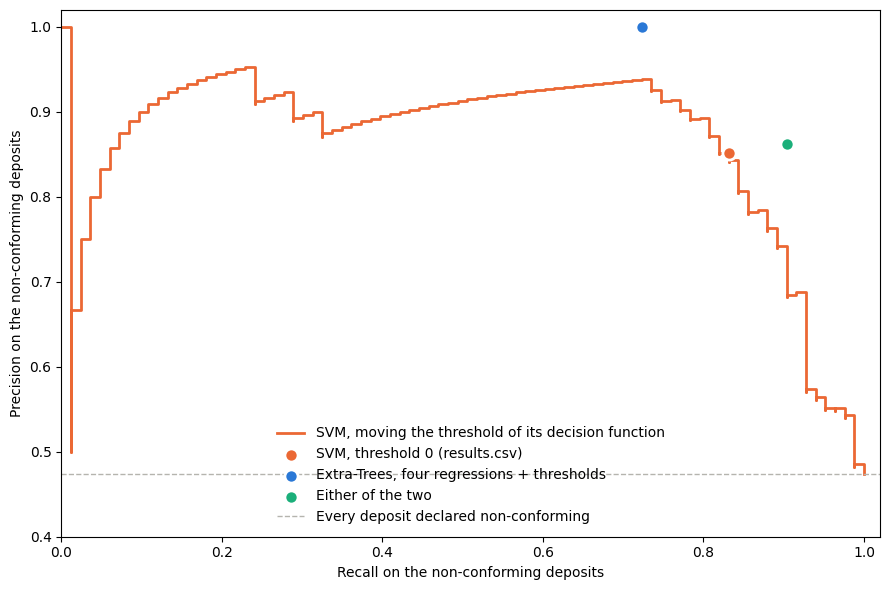

SVM precision at the recall of the Extra-Trees: 0.938
SVM recall at a precision of 0.95 or more: 0.241
SVM precision at a recall of 0.90 or more: 0.743


In [9]:
precision, recall, _ = precision_recall_curve(paired["true_nc"], svm["score"])

points = {
    "SVM, threshold 0 (results.csv)": ("svm", "#eb6834"),
    "Extra-Trees, four regressions + thresholds": ("extra_trees", "#2a78d6"),
    "Either of the two": ("either", "#1baf7a"),
}

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall, precision, color="#eb6834", linewidth=2, drawstyle="steps-post", label="SVM, moving the threshold of its decision function")
for name, (column, color) in points.items():
    ax.scatter(recall_score(paired["true_nc"], paired[column]), precision_score(paired["true_nc"], paired[column]), s=90, color=color, edgecolor="white", linewidth=2, zorder=3, label=name)
ax.axhline(share_nc, color="#b5b4ae", linewidth=1, linestyle="--", label="Every deposit declared non-conforming")
ax.set_xlabel("Recall on the non-conforming deposits")
ax.set_ylabel("Precision on the non-conforming deposits")
ax.set_xlim(0, 1.02)
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=False, loc="lower center")
plt.tight_layout()
plt.show()

curve = pd.DataFrame({"recall": recall, "precision": precision})
print("SVM precision at the recall of the Extra-Trees:", curve.loc[curve["recall"] >= recall_score(paired["true_nc"], paired["extra_trees"]), "precision"].max().round(3))
print("SVM recall at a precision of 0.95 or more:", curve.loc[curve["precision"] >= 0.95, "recall"].max().round(3))
print("SVM precision at a recall of 0.90 or more:", curve.loc[curve["recall"] >= 0.90, "precision"].max().round(3))

The precision and the recall of the SVM when the threshold of its out-of-fold decision function moves away from 0, its default threshold, with the points of the Extra-Trees and of the combination of the two models. The decision functions of the 5 folds are pooled, as if they shared the same scale.

- **At the recall of the Extra-Trees (0.72):** The SVM has a precision of 0.94 at best, against 1.00: for the same share of bad welds caught, the regressions raise fewer false alarms. The SVM never reaches a precision of 0.95 above a recall of 0.24.
- **Higher recall:** Lowering the threshold of the SVM catches more bad welds, at the cost of a precision falling to 0.74 at a recall of 0.90. The regressions of `1B` have no such setting, they would need a safety margin on the thresholds.
- **Either of the two:** Its point (recall of 0.90, precision of 0.86) is above the curve of the SVM: combining the two approaches does better than moving the threshold of the SVM alone, as they do not miss the same deposits.